<a href="https://colab.research.google.com/github/akashakash19/Telco-customer-churn-prediction-using-with-ML/blob/main/Customer_churn__prediction_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"I built a Customer Churn Prediction system using the Telco Customer Churn dataset. The objective was to identify customers who are likely to leave the telecom service. I performed data cleaning, exploratory data analysis, feature engineering, and trained multiple machine learning models. I evaluated them using metrics like Precision, Recall, F1-score, and ROC-AUC, then selected the best-performing model. Finally, I deployed the solution so users could enter customer information and receive a churn prediction with a probability score. The project demonstrates how machine learning can help businesses reduce customer loss by enabling targeted retention strategies."

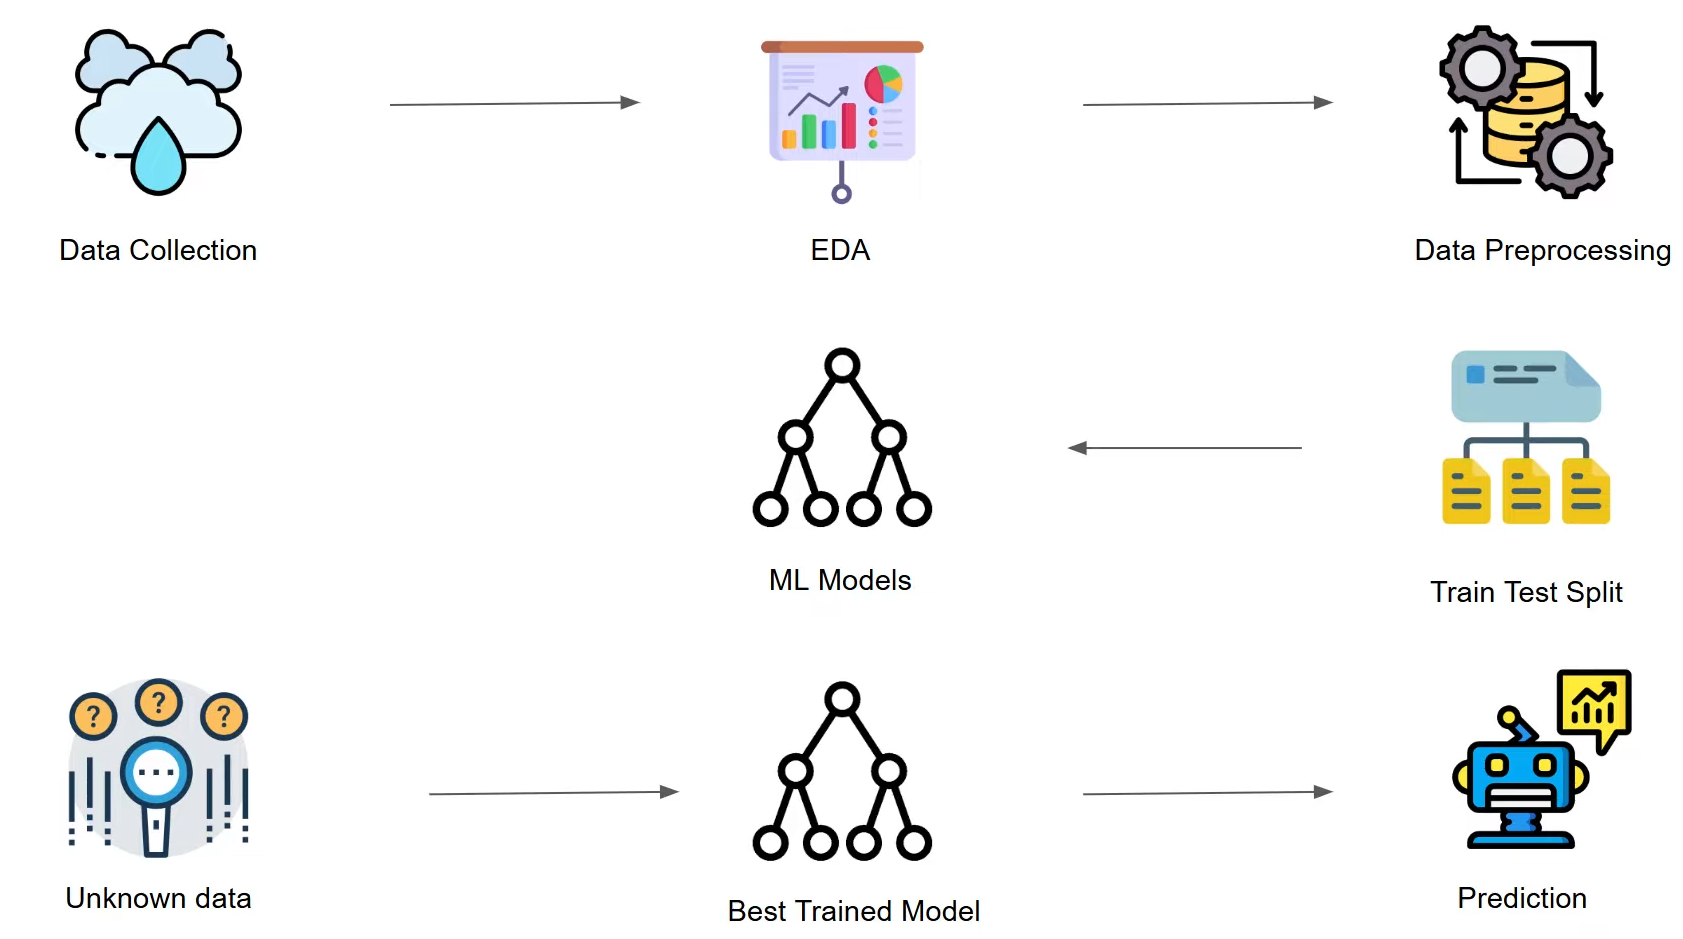

**Import dependencies**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRFClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, roc_auc_score, recall_score, f1_score
import pickle

#**Data loading and Analyzing**

In [ ]:
#load the dataset to frame using with pandas
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn[1].csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
#print first 2lines
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [ ]:
#shape of dataset
df.shape

(7043, 21)

In [ ]:
pd.set_option('display.max_columns', None)  #Display all the columns of the DataFrame without hiding any.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# dropping customerID column becoz that is not require for modeling
df = df.drop(columns = ['customerID'])

In [ ]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
#print separate unique value
print(df['Partner'].unique())

['Yes' 'No']


In [ ]:
#printing the unique values in all the columns
numerical_feature_list = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in df.columns:
  if col not in numerical_feature_list:
    print(col, df[col].unique())
    print("-"*70)

gender ['Female' 'Male']
----------------------------------------------------------------------
SeniorCitizen [0 1]
----------------------------------------------------------------------
Partner ['Yes' 'No']
----------------------------------------------------------------------
Dependents ['No' 'Yes']
----------------------------------------------------------------------
PhoneService ['No' 'Yes']
----------------------------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
----------------------------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
----------------------------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
----------------------------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
----------------------------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
------

In [ ]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
#Important in "TotalCharges" has string elements instead of integer then it has string space
df[df['TotalCharges'] == ' ']



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
print(len(df[df['TotalCharges'] == ' ']))

11


In [ ]:
df['TotalCharges']  == ' '

,TotalCharges
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,False


In [ ]:
df['TotalCharges'] = df['TotalCharges'].replace({" ":"0.0"})

In [ ]:
df['TotalCharges'] = df['TotalCharges'].astype(float)  #string into float

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
#checking the target columns

print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


here we have imbalanced target column we should clean these

#**Exploratory Data Analysis (EDA)**

In [ ]:
df.shape

(7043, 20)

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


**Numerical features Analysis**

In [ ]:
#from matplotlib.lines import lineStyles
#understand the distribution of the numerical features

def plot_histogram(df, column_name):
  plt.figure(figsize=(8,4))
  sns.histplot(df[column_name], kde=True)
  plt.title(f"Distribution of {column_name}")

  #print mean and median values of the column
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

  #add vertical lines for mean and median
  plt.axvline(col_mean, color='red', linestyle='--', linewidth=1, label=f'Mean: {col_mean:.2f}')
  plt.axvline(col_median, color='green', linestyle='-', linewidth=1, label=f'Median: {col_median:.2f}')

  plt.legend()
  plt.show()

In [ ]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


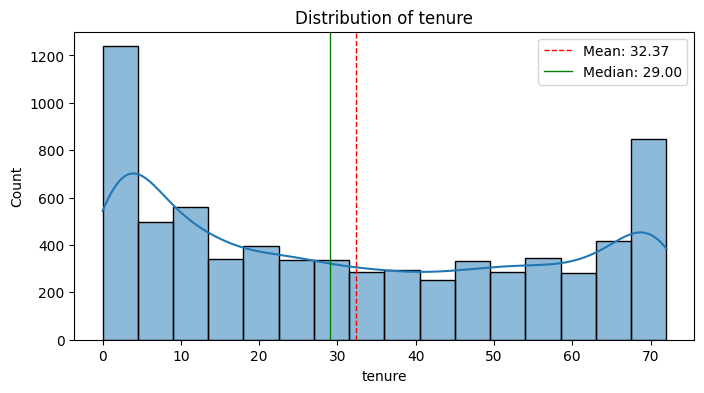

In [ ]:
plot_histogram(df, "tenure") #Its say : How long have customers stayed with the company?

<Axes: xlabel='tenure', ylabel='Count'>

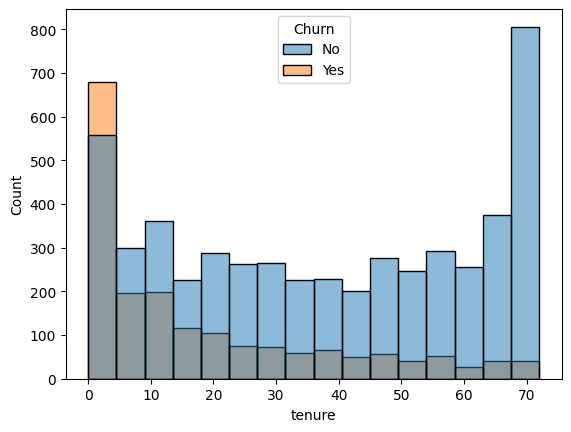

In [ ]:
sns.histplot(data=df, x='tenure', hue='Churn')

**Insight about tenure :**                                        
*The highest churn occurs during the first few months after a customer joins. The company should focus on improving the onboarding experience, providing better customer support, and offering retention incentives to new customers.*

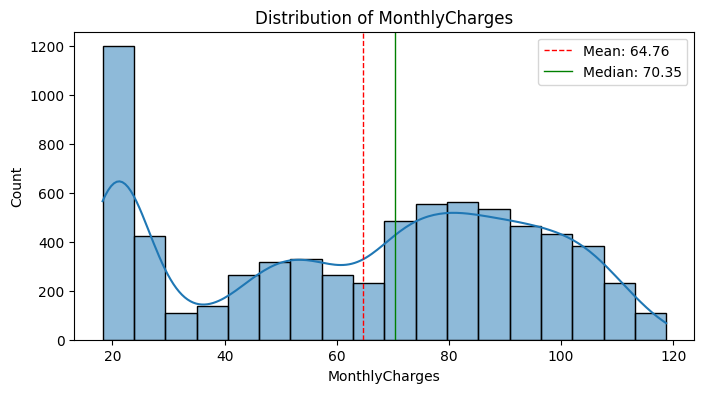

In [ ]:
plot_histogram(df, 'MonthlyCharges')

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

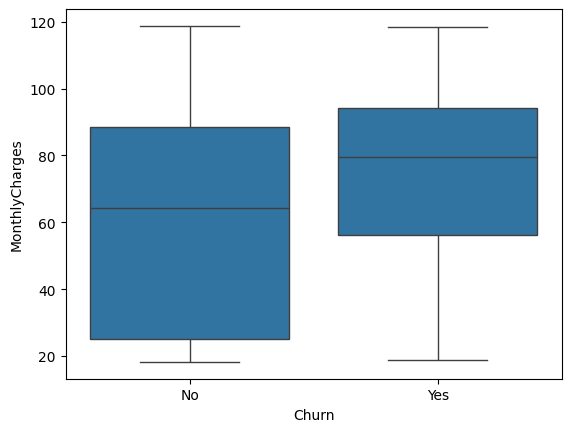

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

**Business Insight**

A possible reason is:

Customers paying high monthly bills expect excellent service.                
If they don't feel they're getting good value, they may switch to another telecom provider.

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

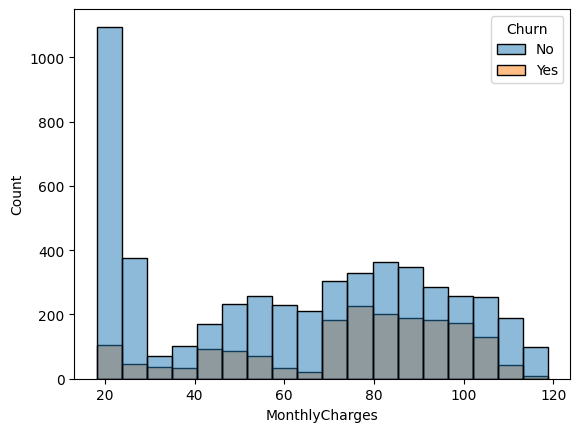

In [ ]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn')

*"Customers paying higher monthly charges are more likely to churn. The company should review its premium plans, improve service quality for these customers, or provide loyalty rewards to increase retention."*

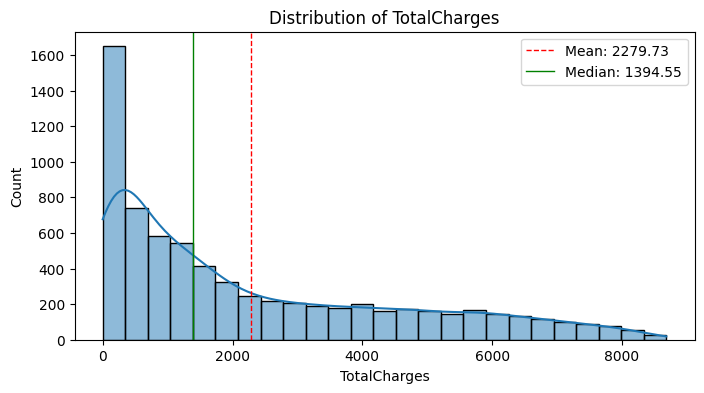

In [ ]:
plot_histogram(df, 'TotalCharges')

<Axes: xlabel='TotalCharges', ylabel='Count'>

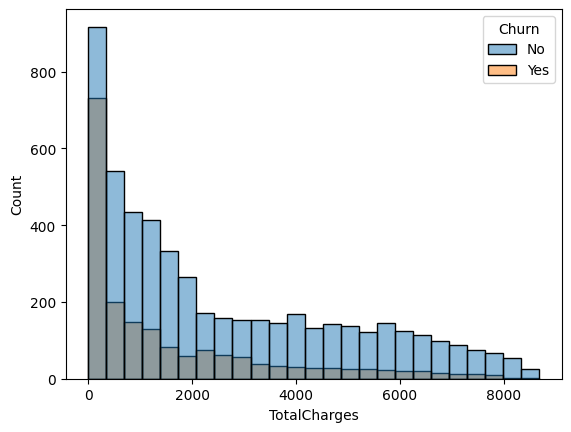

In [ ]:
sns.histplot(data=df, x='TotalCharges', hue='Churn')

*High TotalCharges often indicate long-term customers, who are less likely to leave.*

<Axes: xlabel='Churn', ylabel='TotalCharges'>

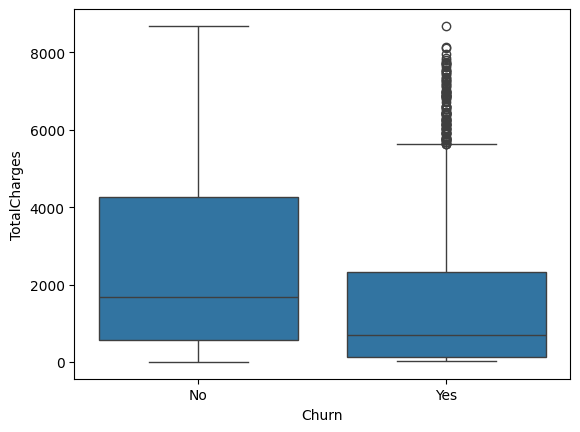

In [ ]:
sns.boxplot(x='Churn', y='TotalCharges', data=df)

*Some loyal customers still churn because of pricing, competition, service quality, or other reasons.*

**Correlation HeatMap of numerical columns**

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

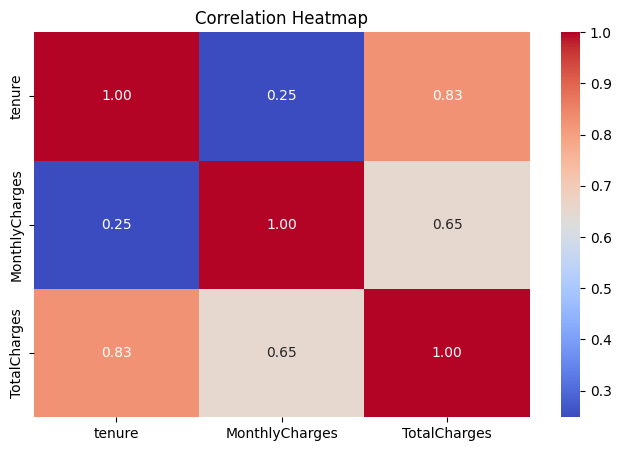

In [ ]:
#correlation matrix heat map
#How strongly two numerical features are related to each other.
plt.figure(figsize=(8,5))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

**Insight of heatmap**

1. Tenure ↔ TotalCharges = 0.83                              
As tenure increases, TotalCharges also increase.

2. MonthlyCharges ↔ TotalCharges = 0.65                 
Customers who pay higher monthly bills generally have higher total bills.      

3. Tenure ↔ MonthlyCharges = 0.25                
This is a weak positive correlation.               
Customers who stay longer do not necessarily pay higher monthly charges.

**Categorical features - Analysis**

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

**Count plot for categorical columns**

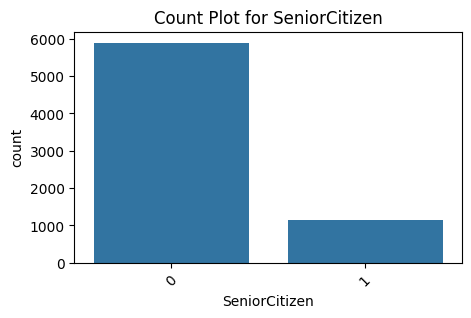

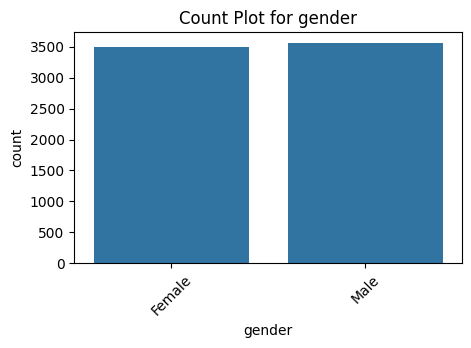

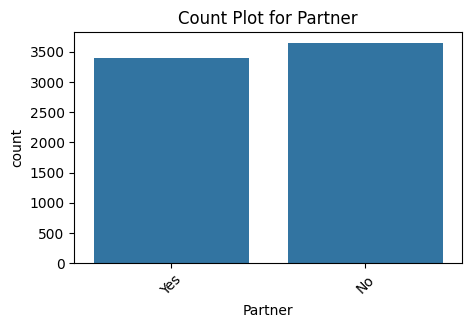

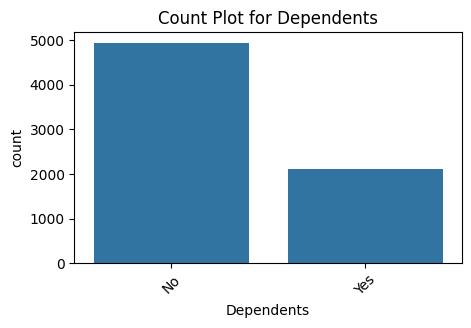

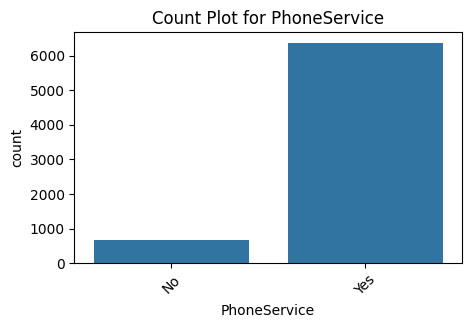

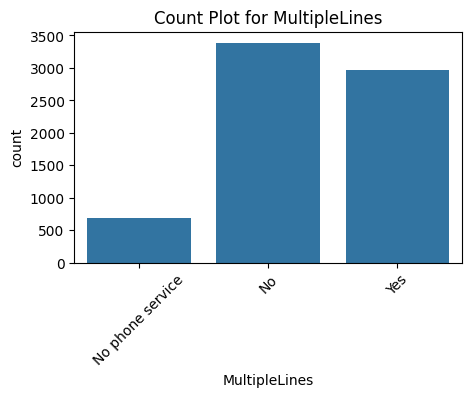

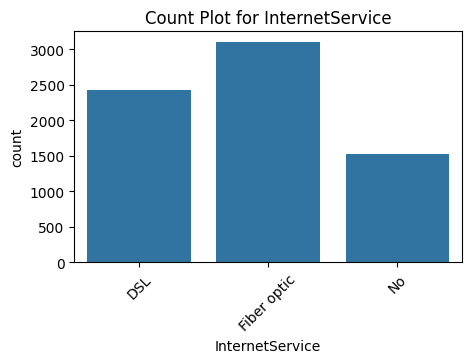

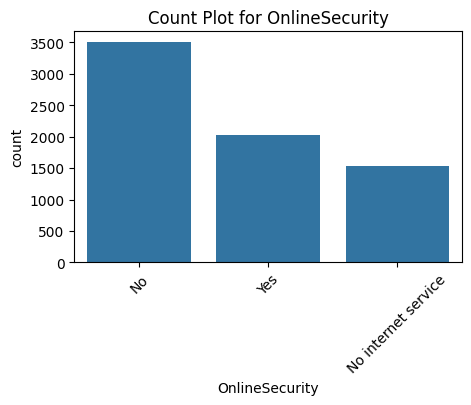

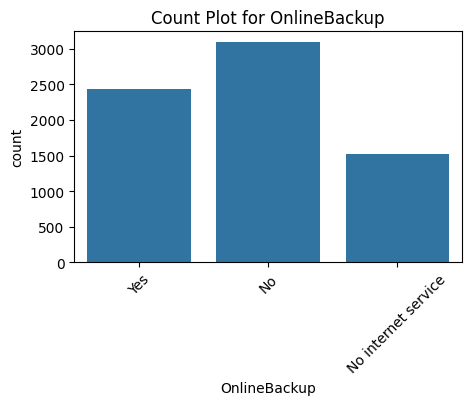

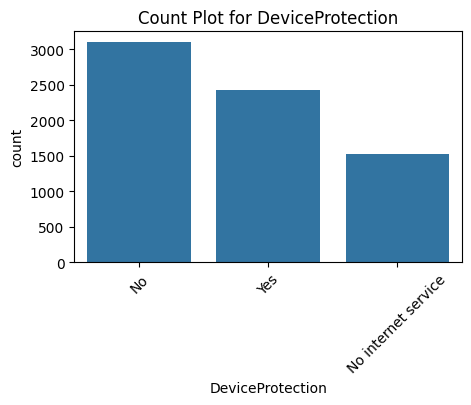

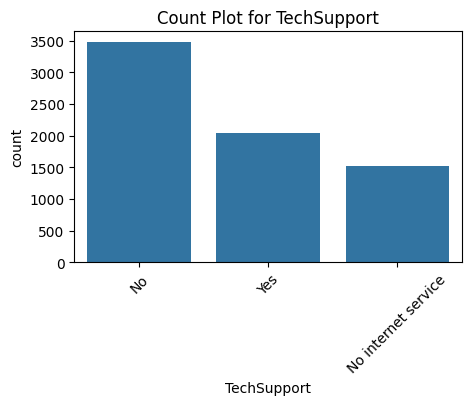

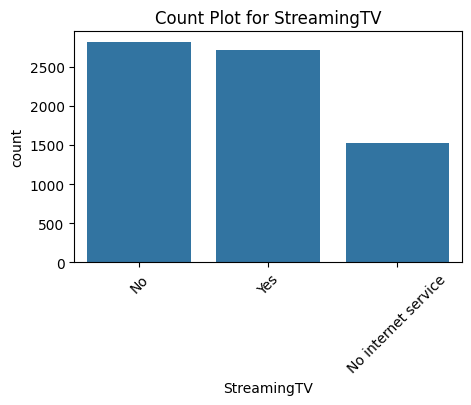

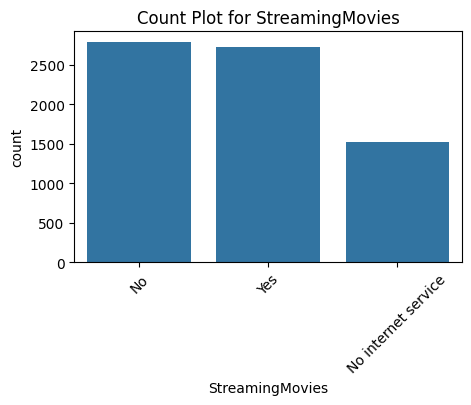

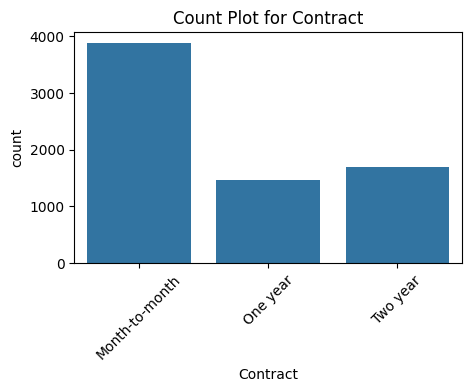

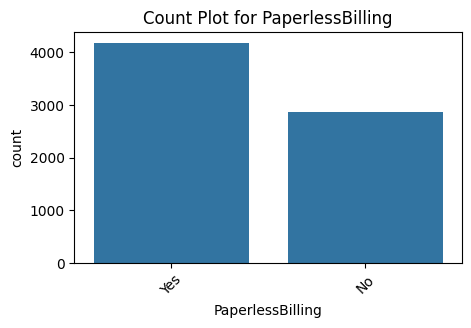

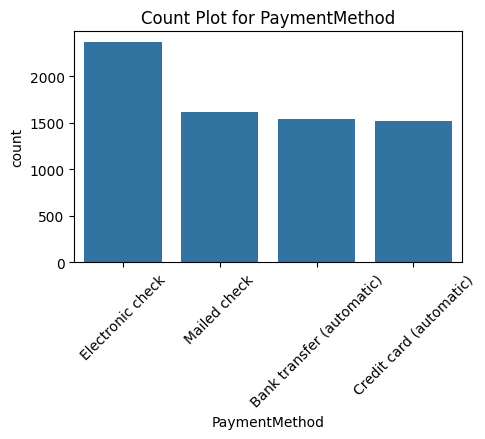

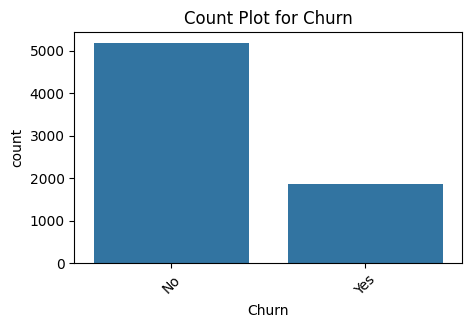

['SeniorCitizen',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [ ]:
object_cols = df.select_dtypes(include='object').columns.to_list()
object_cols = ['SeniorCitizen'] + object_cols

for col in object_cols:
  plt.figure(figsize=(5,3))
  sns.countplot(x = df[col])
  plt.title(f"Count Plot for {col}")
  plt.xticks(rotation=45)
  plt.show()

object_cols

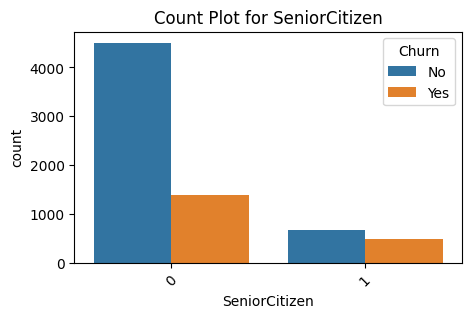

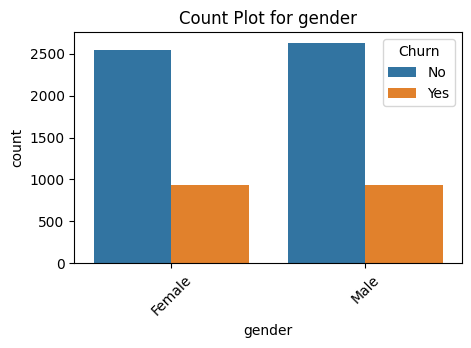

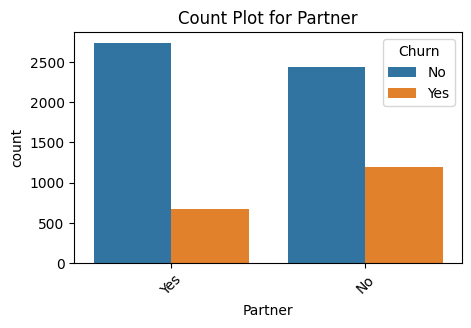

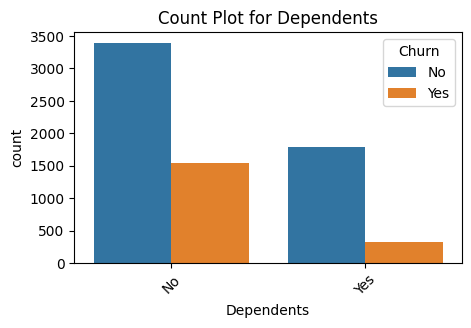

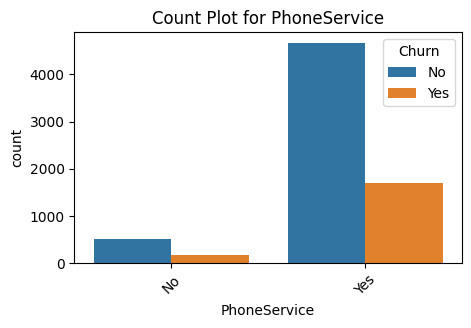

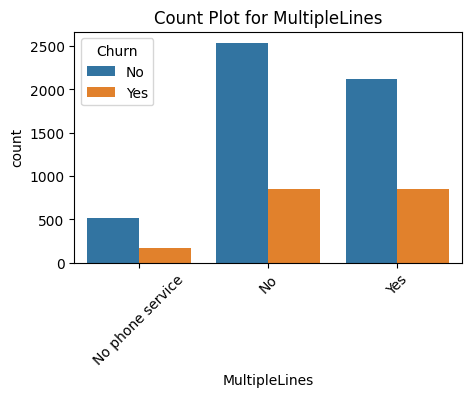

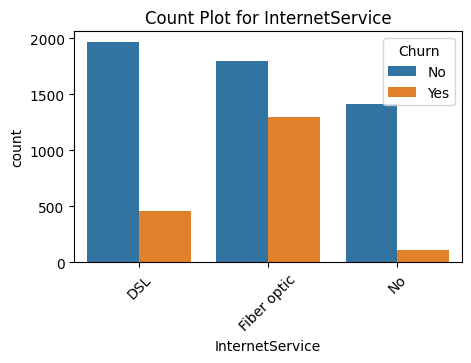

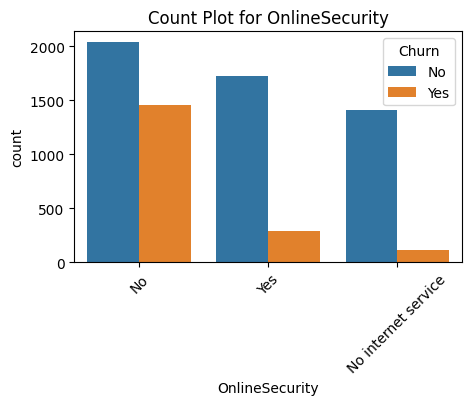

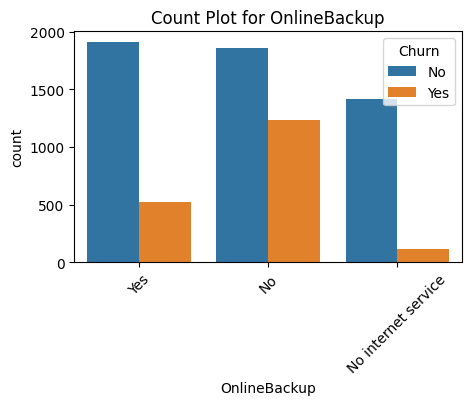

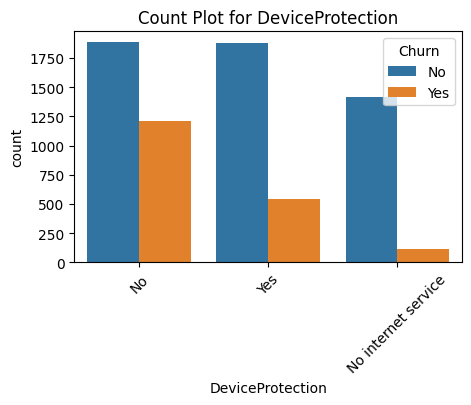

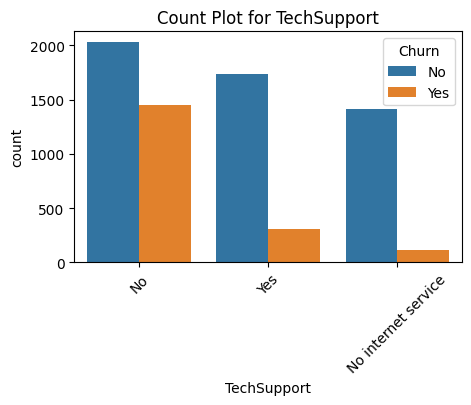

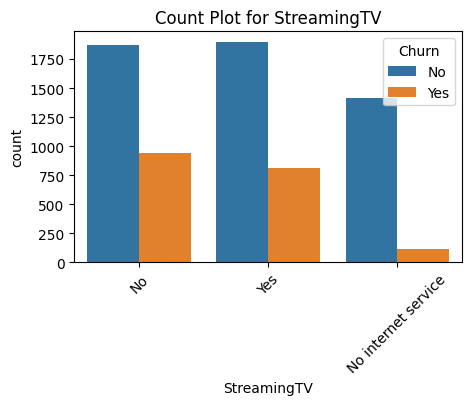

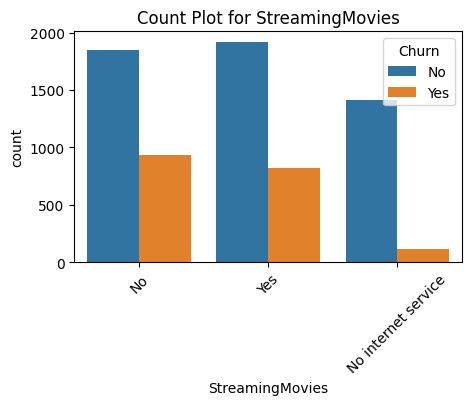

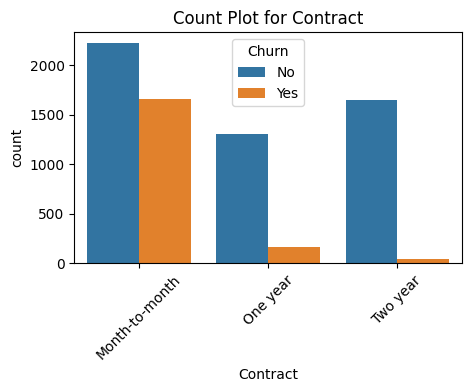

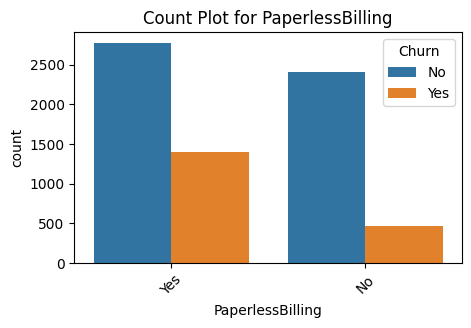

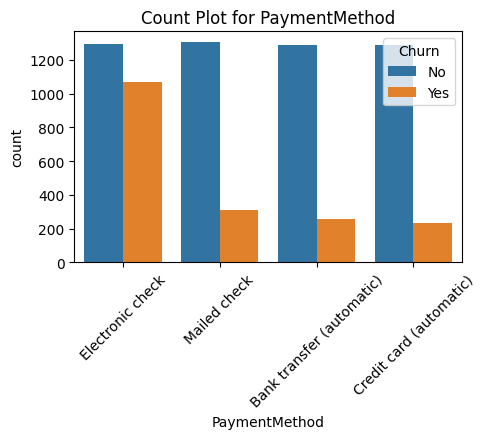

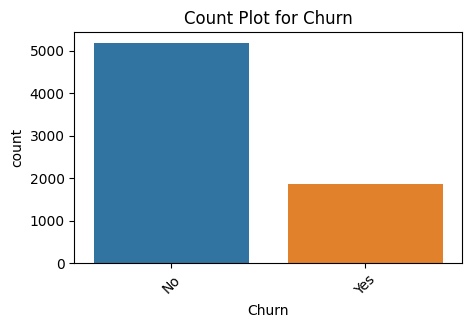

In [ ]:
object_cols = df.select_dtypes(include='object').columns.to_list()
object_cols = ['SeniorCitizen'] + object_cols

for col in object_cols:
  plt.figure(figsize=(5,3))
  sns.countplot(x = df[col], hue=df['Churn'])
  plt.title(f"Count Plot for {col}")
  plt.xticks(rotation=45)
  plt.show()

#**Data processing**

In [ ]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


**Label encoding of target column**

In [ ]:
df['Churn'] = df['Churn'].replace({"Yes" : 1, "No" : 0})

/tmp/ipykernel_668/1324527749.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({"Yes" : 1, "No" : 0})


In [ ]:
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


**Label encoding of categorical columns**

In [ ]:
#identifying columns with object data types

object_cols = df.select_dtypes(include='object').columns
object_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [ ]:
#initialize a dictionary to save the encoders

encoders = {}

#apply label encoders and save the encoders
for column in object_cols:
  label_encoder = LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder

#save the encoders with pickle
with open('label_encoders.pkl','wb') as f:
  pickle.dump(encoders, f)

In [ ]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


*Now change everything in numerical values.*

**Training and testing splitting**

In [ ]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [ ]:
print(X)
print(y)

      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0          0              0        1           0       1             0   
1          1              0        0           0      34             1   
2          1              0        0           0       2             1   
3          1              0        0           0      45             0   
4          0              0        0           0       2             1   
...      ...            ...      ...         ...     ...           ...   
7038       1              0        1           1      24             1   
7039       0              0        1           1      72             1   
7040       0              0        1           1      11             0   
7041       1              1        1           0       4             1   
7042       1              0        0           0      66             1   

      MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0                 1                0     

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 32)

In [ ]:
print("X_train_shape", X_train.shape)
print("X_test_shape", X_test.shape)
print("y_train_shape", y_train.shape)
print("y_test_shape", y_test.shape)

X_train_shape (5634, 19)
X_test_shape (1409, 19)
y_train_shape (5634,)
y_test_shape (1409,)


In [ ]:
print(y_train.value_counts())
print(y_test.value_counts())

Churn
0    4178
1    1456
Name: count, dtype: int64
Churn
0    996
1    413
Name: count, dtype: int64


*The target column has imbalanced datas roughly a 3 : 1 ratio.*

**So we use (SMOTE - Synthetic Minority Over-sampling Technique)**

--SMOTE should be applied only to the training data.

--SMOTE doesn't duplicate the 1400 churn customers.

--Instead, it creates new synthetic churn samples based on existing ones.

In [ ]:
X_train_smote, y_train_smote = SMOTE(random_state=32).fit_resample(X_train, y_train)

In [ ]:
print("X_train_smote :", X_train_smote.shape)
print("y_train_smote :", y_train_smote.shape)

X_train_smote : (8356, 19)
y_train_smote : (8356,)


In [ ]:
print(y_train_smote.value_counts())

Churn
0    4178
1    4178
Name: count, dtype: int64


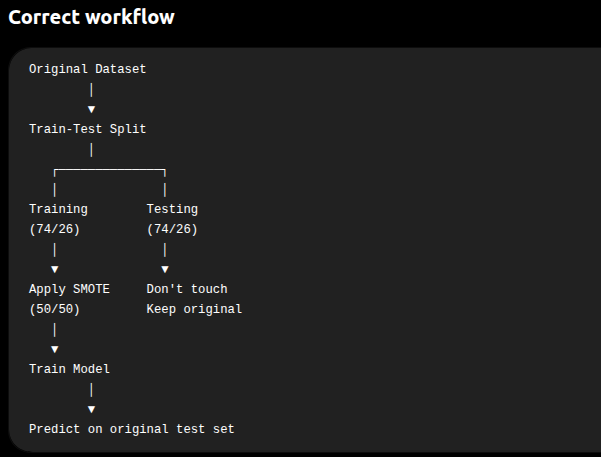

**Model training**

*Training with default parameter*

In [ ]:
#dictionary of models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(random_state = 32),
    "Decision Tree": DecisionTreeClassifier(random_state = 32),
    "Random Forest": RandomForestClassifier(random_state = 32),
    "XGBoost": XGBClassifier(random_state = 32)
}

In [ ]:
#dictionary to store the cross validation results

cv_results = {}

#perform 5-fold cross validation for each model
for model_name, model in models.items():
  print(f"Training {model_name} with default parameters")
  scores = cross_val_score(model, X_train_smote,y_train_smote, cv=5, scoring = "accuracy")
  cv_results[model_name] = scores
  print(f"{model_name} cross validation accuracy: {scores.mean()*100:.2f}%")

Training Logistic Regression with default parameters


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression cross validation accuracy: 79.19%
Training Decision Tree with default parameters
Decision Tree cross validation accuracy: 79.67%
Training Random Forest with default parameters
Random Forest cross validation accuracy: 84.55%
Training XGBoost with default parameters
XGBoost cross validation accuracy: 83.51%


**Insights**

When i got highest accuracy score in Random forest model : 84.55%

In [ ]:
cv_results

{'Logistic Regression': array([0.73983254, 0.7486535 , 0.82046679, 0.83183722, 0.81867145]),
 'Decision Tree': array([0.69437799, 0.73728306, 0.839617  , 0.85637343, 0.85577499]),
 'Random Forest': array([0.73923445, 0.77139437, 0.89587074, 0.91262717, 0.90843806]),
 'XGBoost': array([0.715311  , 0.75044883, 0.89587074, 0.90604428, 0.90783962])}

In [ ]:
rfc = RandomForestClassifier(random_state = 32)

In [ ]:
model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

**Model evalution**

In [ ]:
#Evaluate on test data
y_test_pred = model.predict(X_test)

print("Accuracy score:\n", accuracy_score(y_test, y_test_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification report:\n", classification_report(y_test, y_test_pred))

Accuracy score:
 0.7487579843860894
Confusion matrix:
 [[828 168]
 [186 227]]
Classification report:
               precision    recall  f1-score   support

           0       0.82      0.83      0.82       996
           1       0.57      0.55      0.56       413

    accuracy                           0.75      1409
   macro avg       0.70      0.69      0.69      1409
weighted avg       0.75      0.75      0.75      1409



**We try to apply to find best classification report**

Train and evaluate all models

In [ ]:
results = []

for model_name, model in models.items():

  print('-'*50)
  print("Training", model_name)
  print('-'*50)

  #train smote data
  model.fit(X_train_smote, y_train_smote)

  #predict original test data
  y_pred = model.predict(X_test)

  #probability of ROC AUC
  y_test_prob = model.predict_proba(X_test)[:, -1]

  # Metrics
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  roc_auc = roc_auc_score(y_test, y_test_prob)

  results.append({
      'Model' : model_name,
      'Accuracy' : accuracy,
      'Precision' : precision,
      'Recall' : recall,
      'F1 Score' : f1,
      'ROC AUC' : roc_auc
  })


  print("\nConfusion Matrix:")
  print(confusion_matrix(y_test, y_pred))

  print("\nClassification Report:")
  print(classification_report(y_test, y_pred))

--------------------------------------------------
Training Logistic Regression
--------------------------------------------------

Confusion Matrix:
[[749 247]
 [111 302]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.75      0.81       996
           1       0.55      0.73      0.63       413

    accuracy                           0.75      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.78      0.75      0.75      1409

--------------------------------------------------
Training Decision Tree
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Confusion Matrix:
[[770 226]
 [191 222]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       996
           1       0.50      0.54      0.52       413

    accuracy                           0.70      1409
   macro avg       0.65      0.66      0.65      1409
weighted avg       0.71      0.70      0.71      1409

--------------------------------------------------
Training Random Forest
--------------------------------------------------

Confusion Matrix:
[[836 160]
 [188 225]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       996
           1       0.58      0.54      0.56       413

    accuracy                           0.75      1409
   macro avg       0.70      0.69      0.70      1409
weighted avg       0.75      0.75      0.75      1409

--------------------------------------------------
Training XGBoost
---------------------

**Hyperparameter tuning**

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
#Create the pipeline:
#pipeline = Pipeline([
#    ('smote', SMOTE(random_state = 32)),
#    ('model', LogisticRegression(random_state = 32))
#])

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

In [ ]:
#then find best parameter

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

In [ ]:
#grid search
grid_search = GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    cv = 5,
    scoring = 'recall',
    n_jobs = -1
)

In [ ]:
#train it

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20, 30],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200, 300]},
             scoring='recall')

*The pipeline itself performs:**

**With Pipeline**

Training fold                               
     ↓                                   
SMOTE                                                               
     ↓                                                                        
Logistic Regression

In [ ]:
#Find the best parameters

print("Best parameter")
print(grid_search.best_params_)

Best parameter
{'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [ ]:
print("Best CV Recall:")
print(grid_search.best_score_)

Best CV Recall:
0.6895565598079367


In [ ]:
#Evaluate on your untouched test set

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[799 197]
 [131 282]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83       996
           1       0.59      0.68      0.63       413

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.78      0.77      0.77      1409



**ROC-AUC**

AUC = 0.50 → Random guessing                    
AUC = 0.60 → Poor                              
AUC = 0.70 → Acceptable                                      
AUC = 0.80 → Good                                        
AUC = 0.90 → Excellent                                
AUC = 1.00 → Perfect                                 

In [ ]:
y_prob = best_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8299031476997578


**threshold tuning**

Probability >= 0.50 → Churn                                                
Probability < 0.50  → No Churn

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.30 | Precision: 0.49 | Recall: 0.88 | F1: 0.63
Threshold: 0.35 | Precision: 0.52 | Recall: 0.84 | F1: 0.64
Threshold: 0.40 | Precision: 0.53 | Recall: 0.78 | F1: 0.64
Threshold: 0.45 | Precision: 0.57 | Recall: 0.74 | F1: 0.64
Threshold: 0.50 | Precision: 0.59 | Recall: 0.68 | F1: 0.63
Threshold: 0.55 | Precision: 0.60 | Recall: 0.62 | F1: 0.61
Threshold: 0.60 | Precision: 0.62 | Recall: 0.54 | F1: 0.58


In [ ]:
final_threshold = 0.35

y_pred_final = (y_prob >= final_threshold).astype(int)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print("Final Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

Final Confusion Matrix:
[[676 320]
 [ 68 345]]


In [ ]:
print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_final))


Final Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.68      0.78       996
           1       0.52      0.84      0.64       413

    accuracy                           0.72      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.79      0.72      0.74      1409



In [ ]:
rf_model = best_model.named_steps['model']

In [ ]:
feature_importance = rf_model.feature_importances_

In [ ]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
})

In [ ]:
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

In [ ]:
print(importance_df)

             Feature  Importance
14          Contract    0.214235
4             tenure    0.116252
8     OnlineSecurity    0.115623
11       TechSupport    0.115534
17    MonthlyCharges    0.084524
18      TotalCharges    0.080465
9       OnlineBackup    0.054390
2            Partner    0.041211
7    InternetService    0.033342
16     PaymentMethod    0.031236
3         Dependents    0.029824
10  DeviceProtection    0.024276
0             gender    0.015407
12       StreamingTV    0.009674
13   StreamingMovies    0.009443
6      MultipleLines    0.008889
15  PaperlessBilling    0.006156
1      SeniorCitizen    0.005036
5       PhoneService    0.004481


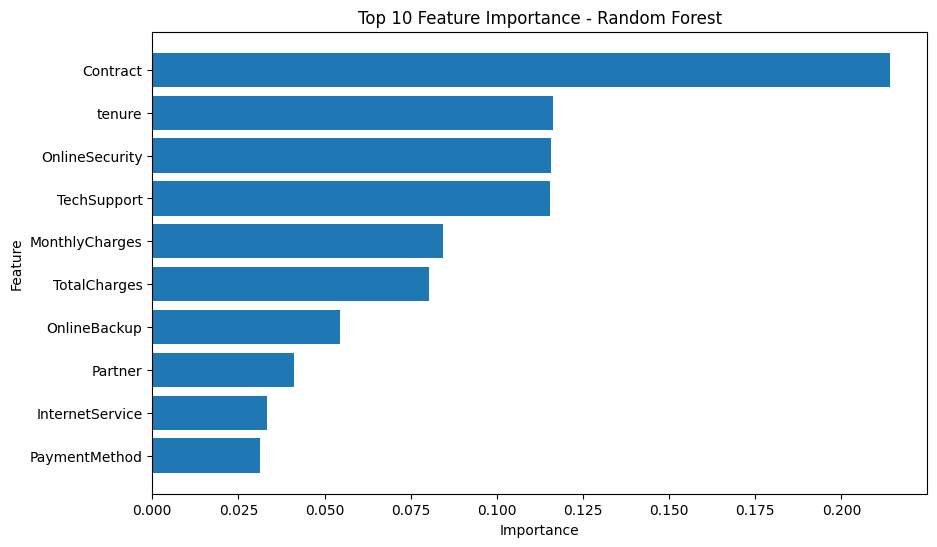

In [ ]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance - Random Forest')

plt.gca().invert_yaxis()
plt.show()

In [ ]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

**SHAP**

In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
best_model

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=4,
                                        random_state=42))])

In [ ]:
rf_model = best_model.named_steps['model']

**Create the SHAP explainer**

In [ ]:
explainer = shap.TreeExplainer(rf_model)

In [ ]:
shap_values = explainer.shap_values(X_test)

In [ ]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [ ]:
print(np.array(shap_values).shape)

(1409, 19, 2)


In [ ]:
print(X_test.shape)

(1409, 19)


In [ ]:
shap_values_churn = shap_values[:, :, 1]

print(shap_values_churn.shape)

(1409, 19)


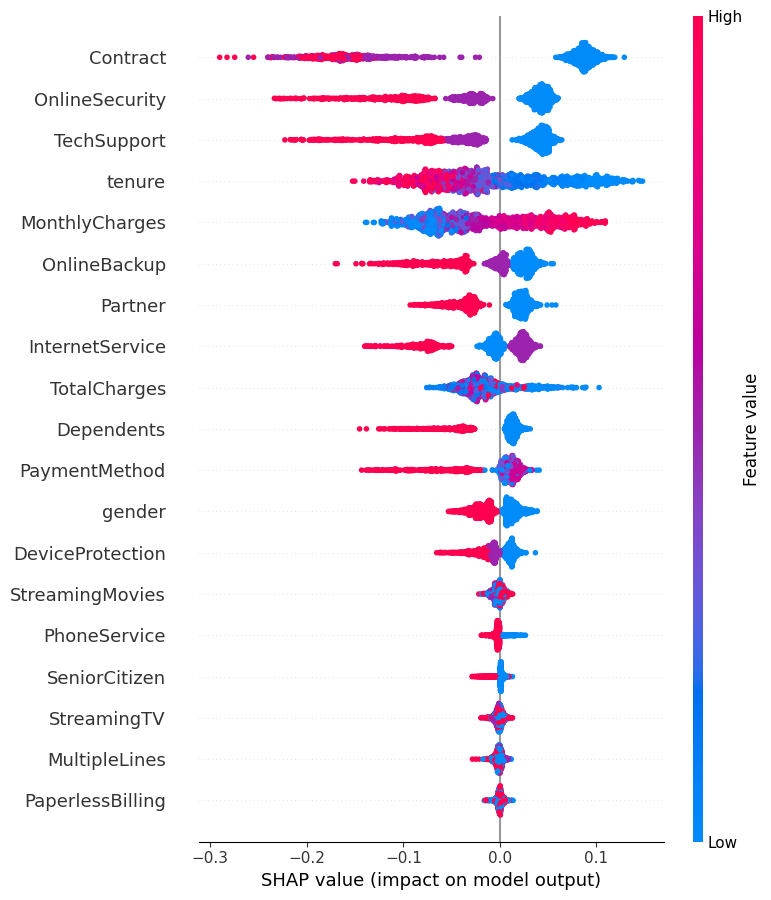

In [ ]:
shap.summary_plot(
    shap_values_churn,
    X_test
)

In [ ]:
for column in object_cols:
    print(column, ":", encoders[column].classes_)

gender : ['Female' 'Male']
Partner : ['No' 'Yes']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No' 'No phone service' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'No internet service' 'Yes']
OnlineBackup : ['No' 'No internet service' 'Yes']
DeviceProtection : ['No' 'No internet service' 'Yes']
TechSupport : ['No' 'No internet service' 'Yes']
StreamingTV : ['No' 'No internet service' 'Yes']
StreamingMovies : ['No' 'No internet service' 'Yes']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['No' 'Yes']
PaymentMethod : ['Bank transfer (automatic)' 'Credit card (automatic)' 'Electronic check'
 'Mailed check']


**Deployment preparation**

In [ ]:
import joblib

joblib.dump(best_model, "churn_model.pkl")

['churn_model.pkl']

In [ ]:
encoders_deploy = {}

categories = {
    'gender': ['Female', 'Male'],
    'Partner': ['No', 'Yes'],
    'Dependents': ['No', 'Yes'],
    'PhoneService': ['No', 'Yes'],
    'MultipleLines': ['No', 'No phone service', 'Yes'],
    'InternetService': ['DSL', 'Fiber optic', 'No'],
    'OnlineSecurity': ['No', 'No internet service', 'Yes'],
    'OnlineBackup': ['No', 'No internet service', 'Yes'],
    'DeviceProtection': ['No', 'No internet service', 'Yes'],
    'TechSupport': ['No', 'No internet service', 'Yes'],
    'StreamingTV': ['No', 'No internet service', 'Yes'],
    'StreamingMovies': ['No', 'No internet service', 'Yes'],
    'Contract': ['Month-to-month', 'One year', 'Two year'],
    'PaperlessBilling': ['No', 'Yes'],
    'PaymentMethod': [
        'Bank transfer (automatic)',
        'Credit card (automatic)',
        'Electronic check',
        'Mailed check'
    ]
}

In [ ]:
for column, values in categories.items():
    encoder = LabelEncoder()
    encoder.fit(values)
    encoders_deploy[column] = encoder

In [ ]:
encoders['Contract']

LabelEncoder()

In [ ]:
encoders = {}

for column in object_cols:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder

In [ ]:
contract_value = encoders_deploy['Contract'].transform(
    ['Month-to-month']
)[0]

print(contract_value)

0


In [ ]:
print(encoders_deploy['Contract'].classes_)

['Month-to-month' 'One year' 'Two year']


In [ ]:
joblib.dump(encoders_deploy, 'encoders.pkl')

['encoders.pkl']

In [ ]:
print(encoders_deploy['Contract'].transform(
    ['Month-to-month', 'One year', 'Two year']
))

print(encoders_deploy['OnlineSecurity'].transform(
    ['No', 'No internet service', 'Yes']
))

[0 1 2]
[0 1 2]


In [ ]:
import joblib

joblib.dump(encoders_deploy, "encoders.pkl")

['encoders.pkl']